In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import set_config
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Output dataframes instead of arrays
set_config(transform_output="pandas")

sacramento = pd.read_csv("dataset/sacramento.csv")
sacramento

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,1005 MORENO WAY,SACRAMENTO,95838,CA,3,2,1410,Residential,Fri May 16 00:00:00 EDT 2008,180000,38.646206,-121.442767
1,10105 MONTE VALLO CT,SACRAMENTO,95827,CA,4,2,1578,Residential,Fri May 16 00:00:00 EDT 2008,190000,38.573917,-121.316916
2,10133 NEBBIOLO CT,ELK GROVE,95624,CA,4,3,2096,Residential,Fri May 16 00:00:00 EDT 2008,289000,38.391085,-121.347231
3,10165 LOFTON WAY,ELK GROVE,95757,CA,3,2,1540,Residential,Fri May 16 00:00:00 EDT 2008,266510,38.387708,-121.436522
4,10254 JULIANA WAY,SACRAMENTO,95827,CA,4,2,2484,Residential,Fri May 16 00:00:00 EDT 2008,331200,38.568030,-121.309966
...,...,...,...,...,...,...,...,...,...,...,...,...
808,9507 SEA CLIFF WAY,ELK GROVE,95758,CA,4,2,2056,Residential,Wed May 21 00:00:00 EDT 2008,285000,38.410992,-121.479043
809,9570 HARVEST ROSE WAY,SACRAMENTO,95827,CA,5,3,2367,Residential,Wed May 21 00:00:00 EDT 2008,315537,38.555993,-121.340352
810,9723 TERRAPIN CT,ELK GROVE,95757,CA,4,3,2354,Residential,Wed May 21 00:00:00 EDT 2008,335750,38.403492,-121.430224
811,9837 CORTE DORADO CT,ELK GROVE,95624,CA,4,2,1616,Residential,Wed May 21 00:00:00 EDT 2008,227887,38.400676,-121.381010


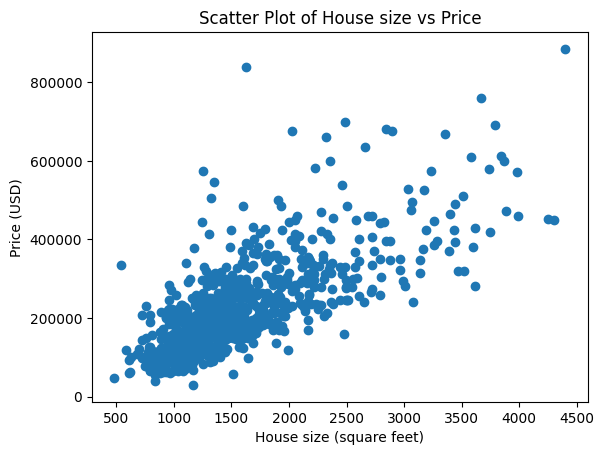

In [4]:
# Plot
plt.scatter(sacramento["sq__ft"], sacramento['price'])

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House size vs Price')
plt.show()

In [6]:
np.random.seed(10)

small_sacramento = sacramento.sample(n=30)
small_sacramento

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
486,7540 HICKORY AVE,ORANGEVALE,95662,CA,3,1,1456,Residential,Thu May 15 00:00:00 EDT 2008,225000,38.703056,-121.235221
399,9013 CASALS ST,SACRAMENTO,95826,CA,2,1,795,Condo,Mon May 19 00:00:00 EDT 2008,126960,38.557045,-121.371670
233,12901 FURLONG DR,WILTON,95693,CA,5,3,3788,Residential,Mon May 19 00:00:00 EDT 2008,691659,38.413535,-121.188211
408,9474 VILLAGE TREE DR,ELK GROVE,95758,CA,4,2,1776,Residential,Mon May 19 00:00:00 EDT 2008,210000,38.413947,-121.408276
549,2901 PINTAIL WAY,ELK GROVE,95757,CA,4,3,3070,Residential,Tue May 20 00:00:00 EDT 2008,495000,38.398488,-121.473424
43,191 BARNHART CIR,SACRAMENTO,95835,CA,4,2,2605,Residential,Fri May 16 00:00:00 EDT 2008,257200,38.675594,-121.515878
181,8316 NORTHAM DR,ANTELOPE,95843,CA,3,2,1235,Residential,Fri May 16 00:00:00 EDT 2008,246544,38.720767,-121.376678
250,2130 CATHERWOOD WAY,SACRAMENTO,95835,CA,3,2,1424,Residential,Mon May 19 00:00:00 EDT 2008,251000,38.675506,-121.510987
140,620 KESWICK CT,GRANITE BAY,95746,CA,4,3,2356,Residential,Fri May 16 00:00:00 EDT 2008,600000,38.732096,-121.219142
392,8593 DERLIN WAY,SACRAMENTO,95823,CA,3,2,1436,Residential,Mon May 19 00:00:00 EDT 2008,180000,38.447585,-121.426627


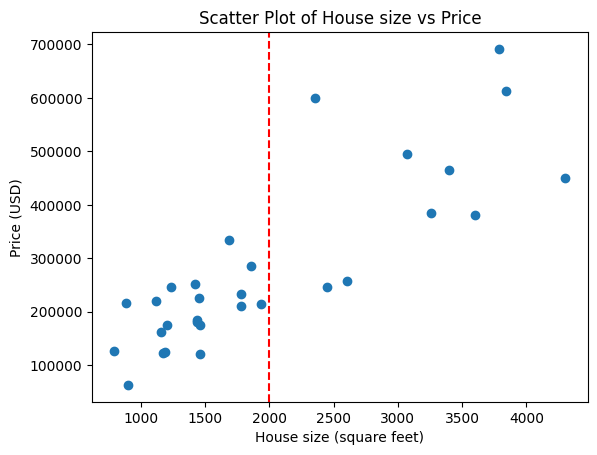

In [7]:
# house size = 2000, sale price?

# Plot
plt.scatter(small_sacramento["sq__ft"], small_sacramento['price'])

# Add a vertical line at 2,000 square feet
plt.axvline(x=2000, color='red', linestyle='--', label='2000 sqft')

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House size vs Price')

plt.show()

In [10]:
#calc abs diff between 2000 and each house size in set
small_sacramento['dist'] = (2000 - small_sacramento['sq__ft']).abs()

In [11]:
nearest_neighbors = small_sacramento.nsmallest(5,'dist')

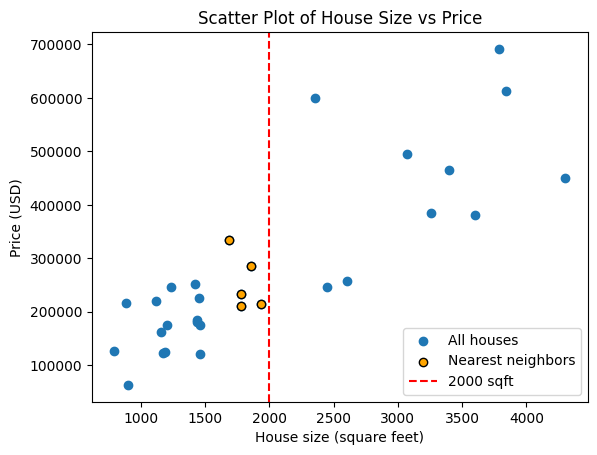

In [12]:
# Scatter plot
plt.scatter(small_sacramento["sq__ft"], small_sacramento['price'], label='All houses')

# Plot nearest neighbors in orange
plt.scatter(nearest_neighbors["sq__ft"], nearest_neighbors['price'], color='orange', label='Nearest neighbors', edgecolor='black')

# Add a vertical line at 2,000 square feet
plt.axvline(x=2000, color='red', linestyle='--', label='2000 sqft')

# Add labels, title, and legend
plt.xlabel("House size (square feet)")
plt.ylabel('Price (USD)')
plt.title('Scatter Plot of House Size vs Price')
plt.legend()

In [13]:
# prediction is avg price of nearest_neighbors
nearest_neighbors['price'].mean()

np.float64(255630.0)

In [ ]:
# Step 1 - split data
sacramento_train, sacramento_test = train_test_split(
    sacramento, train_size=0.75, random_state = 42
)

In [21]:
# step 2 - define predictors and response variables
X_train = sacramento_train[['sq__ft']]
y_train = sacramento_train['price']

In [22]:
# step 3 - init model
knn_regressor = KNeighborsRegressor()

In [23]:
# step 4 - define param grid
param_grid = {
    'n_neighbors': range(1,201,3)
} 

In [24]:
# step 5 - init and fit grid search
sacr_gridsearch = GridSearchCV(
    estimator = knn_regressor,
    param_grid = param_grid,
    cv = 5,
    scoring = "neg_root_mean_squared_error"
)

sacr_gridsearch.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 201, 3)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

In [25]:
results = pd.DataFrame(sacr_gridsearch.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001482,0.000646,0.001924,0.000381,1,{'n_neighbors': 1},-111432.646994,-124930.376771,-111553.640165,-121189.571040,-110534.126317,-115928.072257,5952.545896,67
1,0.001474,0.000679,0.001681,0.000335,4,{'n_neighbors': 4},-84191.452465,-96768.557437,-99395.447194,-91776.634858,-96991.842965,-93824.786984,5417.090443,50
2,0.001253,0.000282,0.001027,0.000043,7,{'n_neighbors': 7},-82055.054082,-94969.980001,-97268.515757,-88221.977923,-90245.964227,-90552.298398,5335.745149,32
3,0.000815,0.000409,0.001257,0.000281,10,{'n_neighbors': 10},-79700.428498,-94364.712988,-95672.079987,-84119.947681,-88172.348589,-88405.903549,6041.754570,19
4,0.001488,0.000428,0.001764,0.000600,13,{'n_neighbors': 13},-77034.701093,-92991.526184,-96360.545374,-84692.931752,-84919.254540,-87199.791789,6815.832448,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,0.001319,0.000283,0.003062,0.000330,187,{'n_neighbors': 187},-89404.692337,-103880.184049,-110873.710254,-98278.819705,-78553.282689,-96198.137807,11280.135742,62
63,0.001535,0.000708,0.002641,0.000495,190,{'n_neighbors': 190},-89807.967415,-104221.691818,-111088.875603,-98698.022523,-78654.732762,-96494.258024,11318.372825,63
64,0.001178,0.000261,0.002679,0.000318,193,{'n_neighbors': 193},-90255.812044,-104469.469062,-111371.637819,-99100.345423,-78654.579110,-96770.368691,11388.795184,64
65,0.001519,0.000522,0.003041,0.000389,196,{'n_neighbors': 196},-90612.174931,-104531.594900,-111725.067577,-99524.332322,-78755.965603,-97029.827067,11433.017471,65


In [26]:
results['mean_test_score'] = results['mean_test_score'].abs()
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001482,0.000646,0.001924,0.000381,1,{'n_neighbors': 1},-111432.646994,-124930.376771,-111553.640165,-121189.571040,-110534.126317,115928.072257,5952.545896,67
1,0.001474,0.000679,0.001681,0.000335,4,{'n_neighbors': 4},-84191.452465,-96768.557437,-99395.447194,-91776.634858,-96991.842965,93824.786984,5417.090443,50
2,0.001253,0.000282,0.001027,0.000043,7,{'n_neighbors': 7},-82055.054082,-94969.980001,-97268.515757,-88221.977923,-90245.964227,90552.298398,5335.745149,32
3,0.000815,0.000409,0.001257,0.000281,10,{'n_neighbors': 10},-79700.428498,-94364.712988,-95672.079987,-84119.947681,-88172.348589,88405.903549,6041.754570,19
4,0.001488,0.000428,0.001764,0.000600,13,{'n_neighbors': 13},-77034.701093,-92991.526184,-96360.545374,-84692.931752,-84919.254540,87199.791789,6815.832448,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,0.001319,0.000283,0.003062,0.000330,187,{'n_neighbors': 187},-89404.692337,-103880.184049,-110873.710254,-98278.819705,-78553.282689,96198.137807,11280.135742,62
63,0.001535,0.000708,0.002641,0.000495,190,{'n_neighbors': 190},-89807.967415,-104221.691818,-111088.875603,-98698.022523,-78654.732762,96494.258024,11318.372825,63
64,0.001178,0.000261,0.002679,0.000318,193,{'n_neighbors': 193},-90255.812044,-104469.469062,-111371.637819,-99100.345423,-78654.579110,96770.368691,11388.795184,64
65,0.001519,0.000522,0.003041,0.000389,196,{'n_neighbors': 196},-90612.174931,-104531.594900,-111725.067577,-99524.332322,-78755.965603,97029.827067,11433.017471,65


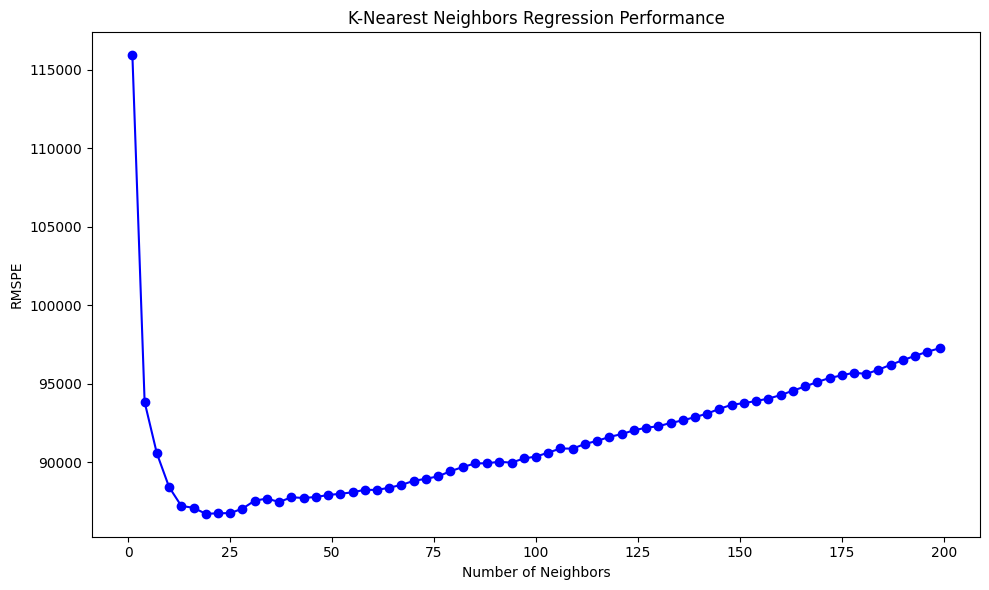

In [27]:
#Create the plot
plt.figure(figsize=(10, 6))

# Plot mean test scores with error bars
plt.plot(results['param_n_neighbors'], results['mean_test_score'], '-o', color='blue')

# Add labels and legend
plt.xlabel('Number of Neighbors')
plt.ylabel('RMSPE')
plt.title('K-Nearest Neighbors Regression Performance')
plt.tight_layout()
plt.show()

In [31]:
# best value of K
sacr_gridsearch.best_params_

{'n_neighbors': 19}

In [33]:
# generate predictions on test set
sacramento_test['predicted'] = sacr_gridsearch.predict(sacramento_test[['sq__ft']])

In [34]:
# calc rmspe
mean_squared_error(
    y_true = sacramento_test['price'],
    y_pred = sacramento_test['predicted']
)**(1/2)

74244.70520282978

In [35]:
# calc r2
r2_score(
    y_true = sacramento_test['price'],
    y_pred = sacramento_test['predicted']
)

0.49520697046011675

c:\Users\Mark\src\gh\lcr\lcr-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


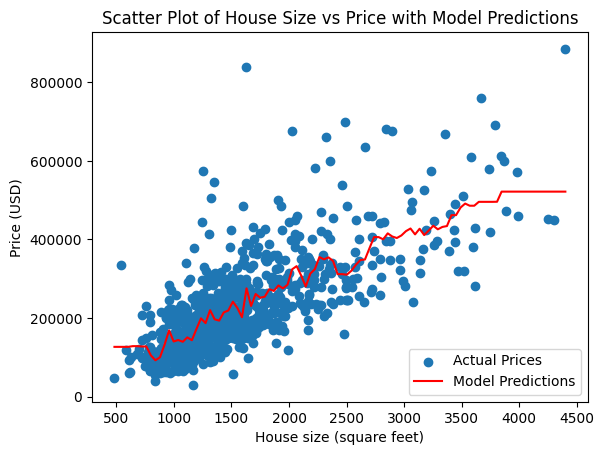

In [37]:
# Generate a range of house sizes for prediction
sizes = np.linspace(sacramento["sq__ft"].min(), sacramento["sq__ft"].max(), 100).reshape(-1, 1)

# Predict house prices for these sizes using the best model from GridSearchCV
predicted_prices = sacr_gridsearch.predict(sizes)

# Plot the original data
plt.scatter(sacramento["sq__ft"], sacramento["price"], label="Actual Prices")

# Plot the model predictions as a line
plt.plot(sizes, predicted_prices, color='red', label="Model Predictions")

# Add labels and legend
plt.xlabel("House size (square feet)")
plt.ylabel("Price (USD)")
plt.title("Scatter Plot of House Size vs Price with Model Predictions")
plt.legend()
plt.show()